# Documentación de APP WEB
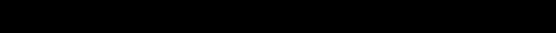
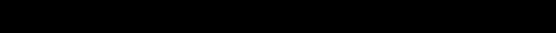
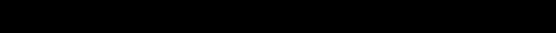
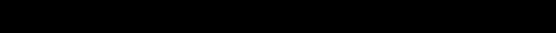

Autores:
- Manuel Elías Orellana Lavayen
- Diego Antonio Murillo Alvarado
- Hernán Andrés Pilozo Rodríguez
- Kelly Naomi Medina Guallo
- Ian Erick López Llorentty
- Miguel Alejandro Yglesias Alvea
- Darío Ramón Robles Ponce

## Archivos utilizados:

- parroquias_ecuador.geojson (GeoJson utilizado para crear capas encima del
mapa)
- dataset.csv (Dataset de predicciones utilizado para obtener riesgo)
- UG_logo.png (Imagen de la Universidad de Guayaquil que se va usar en html)

### Obtención de GeoJson:

https://github.com/Manuel-Orellana/Obtenci-n-de-datos-para-proyecto/tree/d94f9e1024cc06c910bf1c2bdc28c1f2f33301ad/Crecion%20GeoJson%20Parroquias

- Fuente: https://data.humdata.org/dataset/cod-ab-ecu
- Archivo: "ecu_adm_2024/ecu_adm_adm3_2024.shp" (Es un shapefile que
contiene las geometrías de cada parroquia del ecuador)
- De ese archivo se usan únicamente las columnas que contienen el nombre de
los tres niveles y los polígonos
- Se simplifica la geometría (Polígonos) para que sea más rápido de cargar
- Se aplica una normalización a sus columnas de Provincia, Canton y Parroquia
- Se guarda el dataframe como un GeoJson llamado “parroquias_ecuador.geojson”

### Obtención de CSV:

https://github.com/Manuel-Orellana/Obtenci-n-de-datos-para-proyecto/tree/d94f9e1024cc06c910bf1c2bdc28c1f2f33301ad/Creacion_riesgo_inundacion_final

El CSV proviene de las predicciones realizadas por el modelo

## Creación de app.py

- Se importan las librerías necesarias como lo son:
- flask (Útil para creación de página web)
- pandas (útil para manejo de datos tabulares, en este caso el CSV de predicciones)
- folium (Útil para cargar el mapa, aplicar capas y funciones especiales)
- json (Útil para leer el GeoJson de polígonos)
- os (Útil para el manejo de rutas, en especial por la estadía del proyecto en la nube)

### Parte 1 BASE_DIR:

Creamos BASE_DIR usando os, es una variable útil para obtener rutas relativas

### Parte 2 OBJETO APP:

Creamos el objeto “app” usando Flask, se usa __name__ para obtener el nombre
del modulo actual. En este caso __main__

### Parte 3 FUNCIONES:

#### color_riesgo:

Es una función que va a recibir una parroquia (feature cuando hablamos de
GeoJson), y de esa parroquia va sacar su riesgo (Previamente concatenado del
CSV de predicciones). Para mediante su riesgo, darle un color. La función se va
usar al momento de crear las capas para cada una de las parroquias.

#### Resaltar:

Es una función que va a dar ese efecto de resaltado cuando se pase el cursor por
encima de las parroquias. Recibe una Feature aunque no hace nada con él, solo
que es necesario, ya que cuando Folium usa la función si o si le pasa una feature.
En este caso la función cuando es llamada devuelve un diccionario donde se
especifica el grosor, el color y la transparencia del relleno. Su uso se da en la
creación de la capa de riesgo dentro de la función “crear_mapa”

#### cargar_datos:

Es una función que va cargar los datos, recibe una ruta desde un archivo GeoJson y
una ruta de un archivo CSV para leer ambos archivos.
- Primero: renombra las columnas del CSV con las columnas del GeoJson
- Segundo: se ajuste el índice del dataset para la concatenación y se lo guarda en
“pred”
- Tercero: mediante un bucle for se recorren todas las parroquias del GesoJson
- Cuarto: En cada iteración extrae las propiedades de la parroquia
- Quinto: Se crea una clave para buscar llamada “key”, e cual de las propiedades
extrae los tres niveles de búsqueda
- Sexto: Mediante una condicional verifica la existencia de la clave dentro de “pred”
- Séptimo: En caso de existir, agrega a las propiedades de esa parroquia el numero
de inundaciones y el riesgo de inundación
- Octavo: Devuelve el GeoJseon Concatenado

#### calcular_estadisticas

Es una función que recibe el GeoJson que ya contiene todas las propiedades
agregadas, crea una variable con todas las posibles clases de riesgo, agrega un
contador mediante un diccionario por comprensión, recorre todas las parroquias,
por cada parroquia obtiene el riesgo de inundación, parroquia que no tenga riesgo
será catalogada como “sin datos”, se aumenta a el diccionario según la parroquia
y devuelve un conteo.
Esta función solo se va usar para mas adelante agregar información a la leyenda
de  la pagina web

#### crear_mapa

Es la función mas importante por que es la que crea el mapa que luego se lo
convierte a HTML.
Va recibir únicamente de parámetro un GeoJson ya concatenado

1. Se carga el mapa, para esto usamos la función Map de la librería folium,
colocamos la localización de ecuador
2. Creamos la capa que va representar el riesgo de inundación. Usamos
GeoJson de la librería folium, el cual va recibir:
    - GeoJson concatenado
    - función de estilo (color_riesgo)
    - función de resaltado (resaltar)
    - función de Hover : (la cual es “GeoJsonTooltip” de la librería folium),
    donde especificamos que las propiedades que va a usar son los tres
    niveles, luego se le coloca su apodo a los niveles
    - función de pop: (La cual es “GeoJsonPopup” de la librería folium),
    donde va a recibir el riesgo y el número de inundaciones
    • Luego agregamos la capa de riesgo creada a el mapa usando add_to()
3. Creamos capas independientes que van a representar el riesgo de
inundación por provincias. Para ello aplicamos una logica similar a la capa
general del mapa, solo que en este caso se lo hace mediante un bucle for,
de la siguiente manera:
    - Creamos una variable llamada provincias, la cual obtiene el nombre de
    todas las provincias presentes en el GeoJSON. Para ello se recorren
    todas las parroquias, se extrae la propiedad ADM1_ES (provincia) y,
    mediante un conjunto (set), se eliminan los nombres repetidos.
    Finalmente, con sorted() se ordenan alfabéticamente.
    - Recorremos la lista de provincias con un bucle for. En cada iteración se
    trabaja únicamente con una provincia.
    - Dentro del bucle se crea un nuevo GeoJSON temporal llamado
    “geojson_provincia”, el cual contiene únicamente las parroquias
    pertenecientes a la provincia que se está recorriendo. Esto se hace
    filtrando las características cuyo valor de ADM1_ES coincida con la
    provincia actual que recorre el bucle.
    - Para cada GeoJSON filtrado se crea una nueva capa mediante
    folium.GeoJson, asignándole como nombre "Provincia:
    nombre_provincia", de modo que aparezca identificada en el control de
    capas del mapa.
    - A esta nueva capa se le aplican las mismas funciones utilizadas en la
    capa general:
        - Función de estilo (color_riesgo
        - Función de resaltado (resaltar
        - Función Hover (GeoJsonTooltip
        - Función Popup (GeoJsonPopup
        - Finalmente, cada capa creada se agrega al mapa utilizando el método add_to().
4. Agregamos a el mapa con “add_to()” distintas capas de estilos (“calles”,
“claro”, “Oscuro”, “Satelite”)
5. Se agrega una leyenda flotante dentor del mapa qiue va permitir  manipular
todas las funciones que hemos agregado a el mapa, esto con
“LayerControl” de la librería folium
6. Se agrega a el mapa una opción de hacerla pantalla completa, esto con la
función “Fullscreen” de folium y “add_to()”
7. Por último se devuelve el mapa con “._repr_html_()” para que este en html
listo para usar en la pagina html

### Parte 4 USO DE FUNCIONES:

- Se crean las rutas, se cargan los datos y se usa la función “cargar_datos”, el
resultado se lo guarda en una variable llamada “geojson_preparado”
- Se calculan estadísticas del geojson_preparado usando “calcular_estadisticas” y
se las guarda en una variable llamada “estadisticas”
- Se crea el mapa usando la función “crear_mapa” y mandándole como parámetro
el “geojson_preparado”, este mapa se guarda en la variable llamada “mapa”

### Parte 5 CONFIGURACION DE RUTA:

- Mediante el decorador @app.route("/") se define la ruta principal de la aplicación.
El símbolo "/" representa la página de inicio, por lo que esta función será
ejecutada cada vez que un usuario acceda a la dirección principal del sitio web. Se
crea la función inicio(), encargada de generar la página principal que visualizará el
usuario.
- La función inicio lo que hace es usar render_template(), el cual carga el archivo
index.html y reemplaza las expresiones de Jinja2 con los datos enviados desde
Python. La función recibe tanto el mapa como las estadísticas


### Parte 6 CREACION DE CONDICION:

- “if __name__ == "__main__":” verifica que el archivo esté siendo ejecutado
directamente. Si este archivo fuera importado desde otro módulo, el servidor no se
iniciaría automáticamente.
- Luego si cumple con la condición se obtiene el puerto mediante
“int(os.environ.get("PORT", 5000))”
- Y por ultimo inicia el servidro FLASK mediante em método run(), donde el modo
debug esta desactivado

## Creacion de Index.html

Se desarrolla la estructura visual de la aplicación utilizando HTML, donde se
define la distribución de los elementos que observará el usuario. Para el diseño se
utiliza Tailwind CSS, una librería de estilos que permite aplicar clases
directamente en los elementos HTML.

### Paso 1:

Se define la estructura básica de la página mediante las etiquetas html, head y
body. En el bloque head no se muestra a el usuario y solo se cargan los recursos
necesarios como Tailwind CSS, fuentes de Google y estilos personalizados
mediante CSS. 

### Paso 2:

En el body se crea el contenedor principal de la página, donde se organizan las
diferentes secciones:
- Sección de bienvenida: donde se muestra el título del proyecto, el rango
de fechas de los registros y el logo institucional.
- Sección del mapa interactivo: donde se inserta el mapa generado desde
Python mediante la expresión de Jinja:
o La Inserción del mapa generado en Python se hace  usando “{{
mapa|safe }}” el cual es enviado por la función de inicio de app.py
- Sección de cierre: Donde se crean tres bloques, uno con el nombre de
los integrantes, otro con el nombre de fuentes utilizadas y otro con un
texto referente a el proyecto